# Import Libraries

Grid search fusion weight alpha untuk:

```
prob_fused = alpha * prob_text + (1 - alpha) * prob_image
```

In [9]:
import json
import pickle
import re
from pathlib import Path
from urllib.parse import unquote, urlparse
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.base import clone

In [10]:
def clean_url(url):
    parsed = urlparse(url)
    url = parsed.netloc + parsed.path
    url = unquote(url).lower()
    url = re.sub(r"https?:\/\/", "", url)
    url = re.sub(r"[-_/]", " ", url)
    url = re.sub(r"[^a-zA-Z0-9\s]", " ", url)
    url = re.sub(r"(\d)([a-z])", r"\1 \2", url)
    url = re.sub(r"([a-z])(\d)", r"\1 \2", url)
    url = re.sub(r"\s+", " ", url).strip()
    return url

In [11]:
BASE_DIR = Path(".")
BIN_DIR = BASE_DIR / "bin"
CSV_PATH = BASE_DIR / "dataset" / "dataset_crawl_070526_with_images_path.csv"

# Load Models

In [12]:
text_model = tf.keras.models.load_model(str(BIN_DIR / 'text_classifier.keras'))
with open(BIN_DIR / 'text_tfidf_vectorizer.pkl', 'rb') as f:
    text_vectorizer = pickle.load(f)
with open(BIN_DIR / 'text_best_threshold.json') as f:
    text_cfg = json.load(f)
text_threshold = text_cfg.get('best_threshold', 0.63)
print(f'Text threshold: {text_threshold:.2f}')

Text threshold: 0.63


In [13]:
image_model = joblib.load(BIN_DIR / 'image_classifier.pkl')
image_scaler = joblib.load(BIN_DIR / 'image_scaler.pkl')
with open(BIN_DIR / 'image_best_threshold.json') as f:
    image_cfg = json.load(f)
image_threshold = image_cfg['threshold']
print(f'Image threshold: {image_threshold:.2f}')
print(f'Image model: {type(image_model).__name__}')
if hasattr(image_model, 'n_estimators'):
    print(f'n_estimators={image_model.n_estimators}, max_depth={image_model.max_depth}')

Image threshold: 0.54
Image model: RandomForestClassifier
n_estimators=500, max_depth=25


# Load Dataset

In [14]:
df = pd.read_csv(CSV_PATH)
mask = df["Screenshot_Path"].notna() & (df["Screenshot_Path"] != "")
df_img = df[mask].copy().reset_index(drop=True)
X_img = np.load(BIN_DIR / 'image_features.npy')
img_ids = np.load(BIN_DIR / 'image_ids.npy')
id_map = {i: idx for idx, i in enumerate(img_ids)}
order = [id_map[wid] for wid in df_img["Webpage_id"]]
X_img = X_img[order]
y = (df_img["Tag"] == "gambling").astype(int).values
print(f'Samples: {len(df_img)}')
print(f'Gambling: {y.sum()} / Non-gambling: {(1 - y).sum()}')

Samples: 37811
Gambling: 12503 / Non-gambling: 25308


In [15]:
groups = df_img["Domain"].values

gkf = GroupKFold(n_splits=5)

oof_text_probs = np.zeros(len(df_img))
oof_image_probs = np.zeros(len(df_img))

# Predictions from Both Models

In [16]:
for fold, (train_idx, val_idx) in enumerate(
    gkf.split(df_img, y, groups),
    1,
):

    print(f"\nFold {fold}/5")

    # ===================================
    # TEXT MODEL
    # ===================================

    X_text_train = (
        df_img.iloc[train_idx]["Url"]
        .apply(clean_url)
        .values
    )

    X_text_val = (
        df_img.iloc[val_idx]["Url"]
        .apply(clean_url)
        .values
    )

    X_train_tfidf = text_vectorizer.transform(X_text_train)
    X_val_tfidf = text_vectorizer.transform(X_text_val)

    fold_text_model = tf.keras.models.clone_model(
        text_model
    )

    fold_text_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0005
        ),
        loss="binary_crossentropy",
    )

    fold_text_model.fit(
        X_train_tfidf,
        y[train_idx],
        epochs=20,
        batch_size=128,
        verbose=0,
    )

    oof_text_probs[val_idx] = (
        fold_text_model.predict(
            X_val_tfidf,
            verbose=0,
        )
        .ravel()
    )

    # ===================================
    # IMAGE MODEL
    # ===================================

    fold_image_model = clone(image_model)

    fold_image_model.fit(
        X_img[train_idx],
        y[train_idx],
    )

    oof_image_probs[val_idx] = (
        fold_image_model
        .predict_proba(
            X_img[val_idx]
        )[:, 1]
    )


Fold 1/5

Fold 2/5

Fold 3/5

Fold 4/5

Fold 5/5


In [17]:
prob_text = oof_text_probs
prob_image = oof_image_probs

# Grid Search Fusion Weight Alpha

In [18]:
results = []
best_alpha, best_f1, best_th = 0.5, 0.0, 0.5
for alpha in np.arange(0.0, 1.05, 0.05):
    prob_fused = alpha * prob_text + (1.0 - alpha) * prob_image
    best_f1_alpha, best_th_alpha = 0.0, 0.5
    for th in np.arange(0.3, 0.85, 0.02):
        f1 = f1_score(y, (prob_fused >= th).astype(int))
        if f1 > best_f1_alpha:
            best_f1_alpha, best_th_alpha = f1, th
    results.append({'alpha': round(alpha, 2), 'threshold': round(float(best_th_alpha), 2), 'f1': round(float(best_f1_alpha), 4)})
    if best_f1_alpha > best_f1:
        best_f1, best_alpha, best_th = best_f1_alpha, alpha, best_th_alpha

In [19]:
results_df = pd.DataFrame(results)
display(results_df)
text_f1 = f1_score(y, (prob_text >= text_threshold).astype(int))
image_f1 = f1_score(y, (prob_image >= image_threshold).astype(int))
print(f'\nText-only F1 (th={text_threshold:.2f}):  {text_f1:.4f}')
print(f'Image-only F1 (th={image_threshold:.2f}): {image_f1:.4f}')
print(f'\nBest alpha: {best_alpha:.2f}')
print(f'Threshold: {best_th:.2f}')
print(f'Fusion F1: {best_f1:.4f}')

,alpha,threshold,f1
0,0.00,0.48,0.8755
1,0.05,0.50,0.8869
2,0.10,0.52,0.8985
3,0.15,0.50,0.9106
4,0.20,0.50,0.9229
5,0.25,0.52,0.9349
6,0.30,0.50,0.9448
7,0.35,0.46,0.9547
8,0.40,0.46,0.9652
9,0.45,0.46,0.9751



Text-only F1 (th=0.63):  0.9659
Image-only F1 (th=0.54): 0.8724

Best alpha: 0.50
Threshold: 0.50
Fusion F1: 0.9800


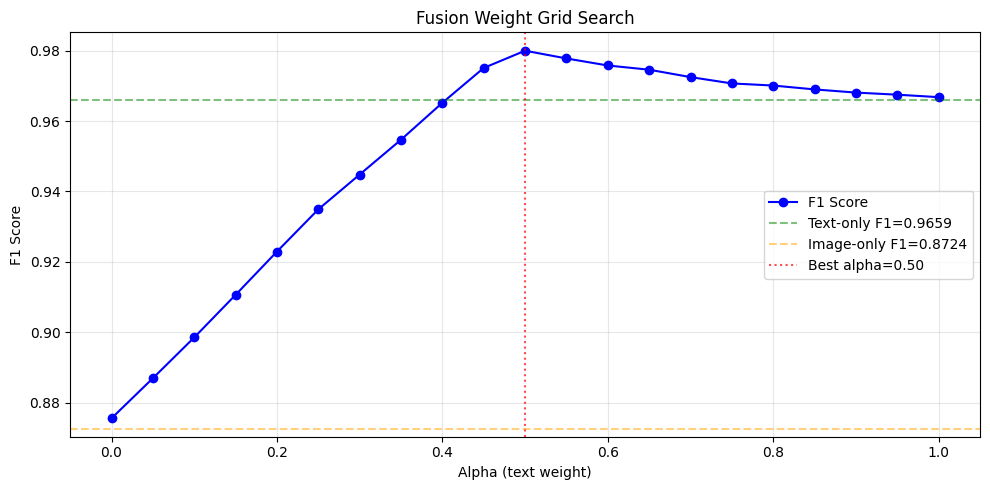

In [20]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(results_df['alpha'], results_df['f1'], 'bo-', label='F1 Score')
ax1.axhline(text_f1, color='green', linestyle='--', alpha=0.5, label=f'Text-only F1={text_f1:.4f}')
ax1.axhline(image_f1, color='orange', linestyle='--', alpha=0.5, label=f'Image-only F1={image_f1:.4f}')
ax1.axvline(best_alpha, color='red', linestyle=':', alpha=0.7, label=f'Best alpha={best_alpha:.2f}')
ax1.set_xlabel('Alpha (text weight)')
ax1.set_ylabel('F1 Score')
ax1.set_title('Fusion Weight Grid Search')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
best_prob_fused = (
    best_alpha * prob_text
    + (1.0 - best_alpha) * prob_image
)

best_pred = (
    best_prob_fused >= best_th
).astype(int)

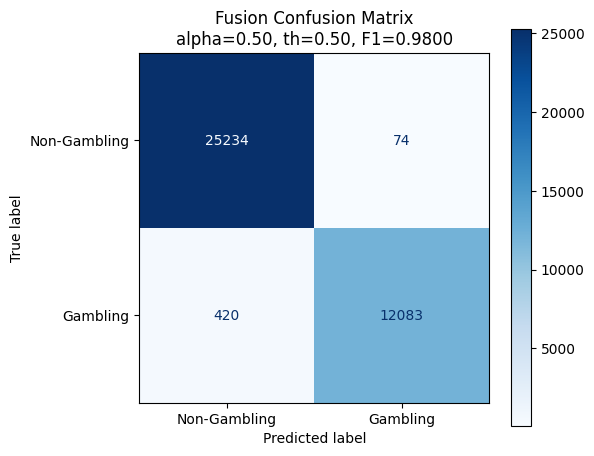

              precision    recall  f1-score   support

Non-Gambling     0.9836    0.9971    0.9903     25308
    Gambling     0.9939    0.9664    0.9800     12503

    accuracy                         0.9869     37811
   macro avg     0.9888    0.9817    0.9851     37811
weighted avg     0.9870    0.9869    0.9869     37811



In [22]:
fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y,
    best_pred,
    display_labels=[
        "Non-Gambling",
        "Gambling",
    ],
    cmap="Blues",
    values_format="d",
    ax=ax,
)

ax.set_title(
    f"Fusion Confusion Matrix\n"
    f"alpha={best_alpha:.2f}, "
    f"th={best_th:.2f}, "
    f"F1={best_f1:.4f}"
)

plt.tight_layout()
plt.show()

print(
    classification_report(
        y,
        best_pred,
        target_names=[
            "Non-Gambling",
            "Gambling",
        ],
        digits=4,
    )
)

# Save Optimal Alpha

In [23]:
output = {'alpha': float(best_alpha), 'threshold': float(best_th), 'f1': float(best_f1)}
with open(BIN_DIR / 'image_fusion_alpha.json', 'w') as f:
    json.dump(output, f)
print(f'Saved to {BIN_DIR / "image_fusion_alpha.json"}')
print(json.dumps(output, indent=2))

Saved to bin/image_fusion_alpha.json
{
  "alpha": 0.5,
  "threshold": 0.5000000000000002,
  "f1": 0.9799675587996756
}
